## Part 1: Building the CNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing the Keras libraries**

In [2]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

**Initializing the CNN**

In [4]:
classifier = Sequential()

**Step 1: Convolution**

In [5]:
classifier.add(Conv2D(32,(3,3), input_shape=(64,64,3),activation = 'relu'))

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D

**Step 2: Pooling**

In [6]:
classifier.add(MaxPooling2D(pool_size=(2,2)))

**Adding a second convolutional layer**

In [7]:
classifier.add(Conv2D(32,(3,3),activation = 'relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))

**Step 3: Flattening**

In [8]:
classifier.add(Flatten())

**Step 4: Full connection**

In [9]:
classifier.add(Dense(units= 128, activation = 'relu'))
classifier.add(Dense(units=1, activation = 'sigmoid'))

**Compiling the CNN**

In [10]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
classifier.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 6272)              0         
                                                                 
 dense (Dense)               (None, 128)              


## Part 2: Fitting the CNN to the images

**Data generator and fit to the data**

In [12]:
from keras.preprocessing.image import ImageDataGenerator

In [13]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_set = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/DL ISGI/2_CNN_ImageClassification/dataset/training_set',
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary')
test_set = test_datagen.flow_from_directory(
        '/content/drive/MyDrive/DL ISGI/2_CNN_ImageClassification/dataset/test_set',
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary')

Found 8030 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [14]:
history = classifier.fit(train_set,steps_per_epoch=250,epochs=25,validation_data=test_set,validation_steps=63)

Epoch 1/25
250/250 [==============================] - 2007s 8s/step - loss: 0.6774 - accuracy: 0.5678 - val_loss: 0.6369 - val_accuracy: 0.6360
Epoch 2/25
250/250 [==============================] - 42s 168ms/step - loss: 0.6285 - accuracy: 0.6518 - val_loss: 0.6043 - val_accuracy: 0.7000
Epoch 3/25
250/250 [==============================] - 45s 181ms/step - loss: 0.5972 - accuracy: 0.6783 - val_loss: 0.5519 - val_accuracy: 0.7390
Epoch 4/25
250/250 [==============================] - 40s 161ms/step - loss: 0.5614 - accuracy: 0.7099 - val_loss: 0.5265 - val_accuracy: 0.7450
Epoch 5/25
250/250 [==============================] - 41s 163ms/step - loss: 0.5232 - accuracy: 0.7404 - val_loss: 0.6075 - val_accuracy: 0.6950
Epoch 6/25
250/250 [==============================] - 40s 161ms/step - loss: 0.5006 - accuracy: 0.7537 - val_loss: 0.4936 - val_accuracy: 0.7745
Epoch 7/25
250/250 [==============================] - 40s 159ms/step - loss: 0.4848 - accuracy: 0.7676 - val_loss: 0.4779 - val_acc

**Metrics visualization**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
training_loss = history.history['loss']
test_loss = history.history['val_loss']

In [ ]:
epoch_count = range(1, len(training_loss)+1)

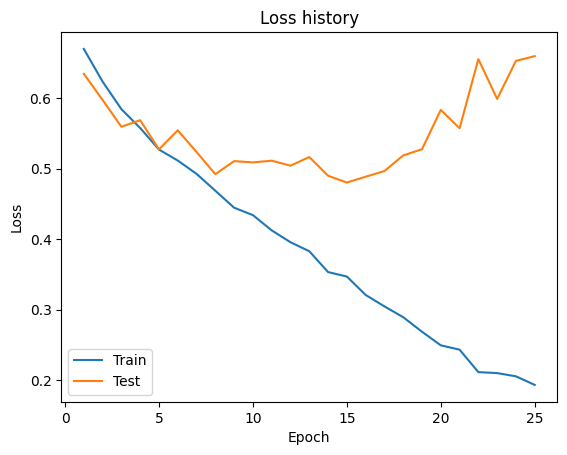

In [ ]:
plt.plot(epoch_count, training_loss)
plt.plot(epoch_count, test_loss)
plt.title('Loss history')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'])

In [ ]:
training_acc = history.history['accuracy']
test_acc = history.history['val_accuracy']

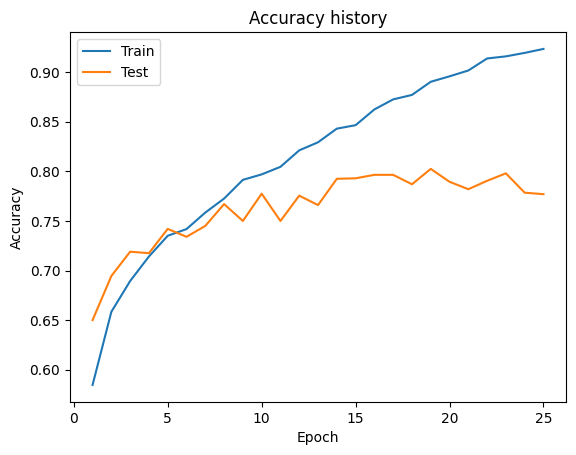

In [ ]:
plt.plot(epoch_count, training_acc)
plt.plot(epoch_count, test_acc)
plt.title('Accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])

## Part 3: Making new predictions

In [ ]:
import numpy as np
from keras.preprocessing import image
test_image = image.load_img('/content/drive/MyDrive/DL ISGI/2_CNN_ImageClassification/dataset/single_prediction/cat_or_dog_1.jpg',target_size=(64,64))

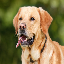

In [ ]:
test_image

In [ ]:
test_image = image.img_to_array(test_image)
test_image /= 255

In [ ]:
test_image.shape

(64, 64, 3)

In [ ]:
test_image

array([[[0.21176471, 0.22745098, 0.02745098],
        [0.22745098, 0.24705882, 0.03529412],
        [0.2509804 , 0.2627451 , 0.03921569],
        ...,
        [0.53333336, 0.5647059 , 0.2784314 ],
        [0.54901963, 0.5882353 , 0.3019608 ],
        [0.54509807, 0.58431375, 0.30588236]],

       [[0.1882353 , 0.21176471, 0.02352941],
        [0.2       , 0.22745098, 0.02745098],
        [0.22745098, 0.24705882, 0.03529412],
        ...,
        [0.5058824 , 0.5372549 , 0.2509804 ],
        [0.54509807, 0.58431375, 0.30588236],
        [0.5529412 , 0.5921569 , 0.3137255 ]],

       [[0.1882353 , 0.21960784, 0.02745098],
        [0.1882353 , 0.21960784, 0.02745098],
        [0.21176471, 0.23921569, 0.03921569],
        ...,
        [0.48235294, 0.5058824 , 0.25490198],
        [0.53333336, 0.5686275 , 0.3137255 ],
        [0.54901963, 0.58431375, 0.32156864]],

       ...,

       [[0.18039216, 0.21568628, 0.04705882],
        [0.16470589, 0.19607843, 0.04313726],
        [0.14901961, 0

In [ ]:
test_image = np.expand_dims(test_image,axis=0)
result = classifier.predict(test_image)

1/1 [==============================] - 0s 157ms/step


In [ ]:
result = result[0][0]>0.5

In [ ]:
if result == True:
    prediction = 'dog'
else:
    prediction = 'cat'

print(prediction)

dog
